In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Carga de datos
df = pd.read_csv('server_logs.csv')

# Convertir la columna de timestamp a formato datetime
df['timestamp_event'] = pd.to_datetime(df['timestamp_event'])

# 6.1 Exploración inicial
print("--- Exploración Inicial ---")
print(f"Total de logs: {len(df)}")
print("\nConteo por severidad:")
print(df['severity'].value_counts())
print("\nServicio con más logs:", df['service_name'].value_counts().idxmax())
print("Servicio con menos logs:", df['service_name'].value_counts().idxmin())
print("\nMensaje más repetido:", df['message'].mode()[0])

--- Exploración Inicial ---
Total de logs: 5795

Conteo por severidad:
severity
INFO        3542
WARN        1358
ERROR        775
CRITICAL     120
Name: count, dtype: int64

Servicio con más logs: api-gateway
Servicio con menos logs: notification-service

Mensaje más repetido: Health check OK


In [3]:
# Definir eventos malos (Bad Events)
condicion_bad = (df['severity'].isin(['ERROR', 'CRITICAL'])) | (df['status_code'] >= 500)
df['is_bad'] = condicion_bad

# Agrupar en ventanas de 5 minutos
# total_events: cuenta todos; bad_events: suma los booleanos (True=1, False=0)
bins = df.resample('5min', on='timestamp_event').agg(
    total_events=('message', 'count'),
    bad_events=('is_bad', 'sum')
)

# Calcular Bad Rate
bins['bad_rate'] = bins['bad_events'] / bins['total_events']

# 6.2 Detección del momento crítico (Filtro >= 20 eventos)
top_5_criticos = bins[bins['total_events'] >= 20].sort_values(by='bad_rate', ascending=False).head(5)
print("\n--- Top 5 Momentos Críticos ---")
print(top_5_criticos)

# Seleccionar el Top 1 (Momento Crítico)
momento_critico_time = top_5_criticos.index[0]



--- Top 5 Momentos Críticos ---
                           total_events  bad_events  bad_rate
timestamp_event                                              
2026-01-10 11:10:00+00:00           189         110  0.582011
2026-01-10 11:15:00+00:00           228         129  0.565789
2026-01-10 11:20:00+00:00           111          59  0.531532
2026-01-11 14:35:00+00:00           255         117  0.458824
2026-01-11 14:30:00+00:00           156          68  0.435897


In [4]:
# Filtrar el dataframe original para el momento crítico
start_time = momento_critico_time
end_time = start_time + pd.Timedelta(minutes=5)
df_critico = df[(df['timestamp_event'] >= start_time) & (df['timestamp_event'] < end_time)]

# Diagnóstico
print(f"\n--- Diagnóstico del momento: {start_time} ---")
print("Bad events por servicio:\n", df_critico[df_critico['is_bad']]['service_name'].value_counts())
print("\nTop 5 mensajes en bad events:\n", df_critico[df_critico['is_bad']]['message'].value_counts().head(5))
print("\nTop 5 endpoints comprometidos (por cantidad de errores):\n", 
      df_critico[df_critico['is_bad']]['endpoint'].value_counts().head(5))

# 6.4 Comparación Incidente vs Baseline
df_baseline = df[~((df['timestamp_event'] >= start_time) & (df['timestamp_event'] < end_time))]

comparacion = pd.DataFrame({
    'Metrica': ['Total Events', 'Bad Rate', 'Avg Latency (ms)', '% 5xx'],
    'Incidente': [
        len(df_critico),
        df_critico['is_bad'].mean(),
        df_critico['latency_ms'].mean(),
        (df_critico['status_code'] >= 500).mean() * 100
    ],
    'Baseline': [
        len(df_baseline),
        df_baseline['is_bad'].mean(),
        df_baseline['latency_ms'].mean(),
        (df_baseline['status_code'] >= 500).mean() * 100
    ]
})
print("\n--- Comparación Incidente vs Baseline ---")
print(comparacion)


--- Diagnóstico del momento: 2026-01-10 11:10:00+00:00 ---
Bad events por servicio:
 service_name
orders-service       72
inventory-service    37
payment-service       1
Name: count, dtype: int64

Top 5 mensajes en bad events:
 message
Order creation failed - inventory lock timeout    72
Database deadlock detected                        37
External dependency error                          1
Name: count, dtype: int64

Top 5 endpoints comprometidos (por cantidad de errores):
 endpoint
/orders/cancel    26
/orders/create    25
/orders/status    21
/inv/reserve      18
/inv/stock        13
Name: count, dtype: int64

--- Comparación Incidente vs Baseline ---
            Metrica    Incidente     Baseline
0      Total Events   189.000000  5606.000000
1          Bad Rate     0.582011     0.140029
2  Avg Latency (ms)  1589.687831   521.094363
3             % 5xx    58.201058    14.002854


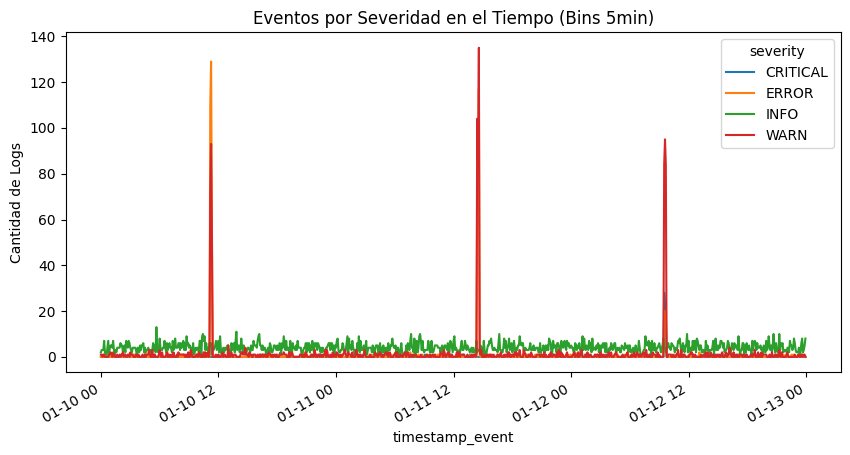

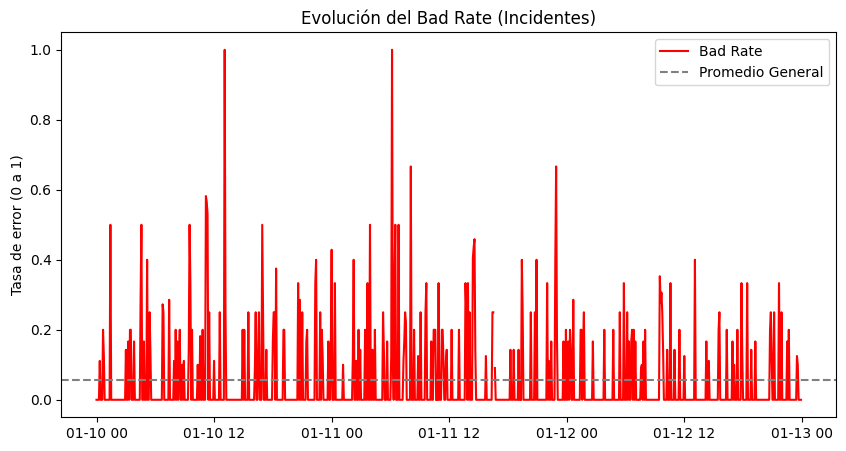

In [5]:
# Gráfico 1: Conteo por severidad en el tiempo
severity_time = df.groupby([pd.Grouper(key='timestamp_event', freq='5min'), 'severity']).size().unstack(fill_value=0)
severity_time.plot(kind='line', figsize=(10, 5))
plt.title('Eventos por Severidad en el Tiempo (Bins 5min)')
plt.ylabel('Cantidad de Logs')
plt.show()

# Gráfico 2: Bad Rate en el tiempo
plt.figure(figsize=(10, 5))
plt.plot(bins.index, bins['bad_rate'], color='red', label='Bad Rate')
plt.title('Evolución del Bad Rate (Incidentes)')
plt.ylabel('Tasa de error (0 a 1)')
plt.axhline(y=bins['bad_rate'].mean(), color='gray', linestyle='--', label='Promedio General')
plt.legend()
plt.show()

Conclusión del Incidente:
El sistema experimentó su momento crítico a las [Hora del top 1], donde el bad rate alcanzó un [Valor bad_rate]. El servicio que sufrió la mayor degradación fue [Nombre del Servicio], afectando principalmente al endpoint [Nombre del Endpoint]. La causa principal identificada en los logs fue el error: "[Mensaje dominante]". Al comparar este incidente con el baseline de operaciones, observamos que el porcentaje de errores 5xx se disparó del [% baseline]% al [% incidente]%, confirmando la severidad del evento.